In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree  import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/Decision Tree  - Assignment -4/iphone_purchase_records.csv')
df.head()

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


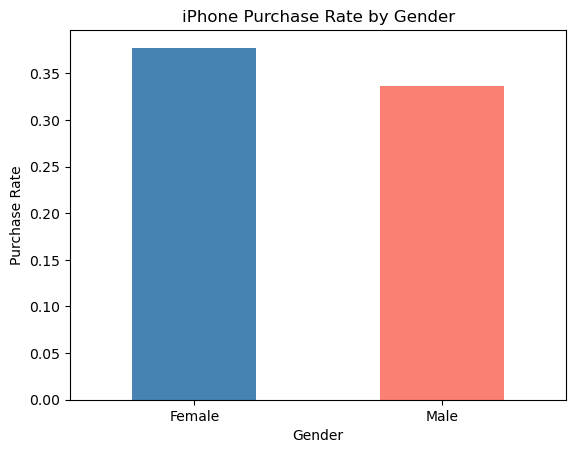

In [3]:
import matplotlib.pyplot as plt

df.groupby('Gender')['Purchase Iphone'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('iPhone Purchase Rate by Gender')
plt.ylabel('Purchase Rate')
plt.xticks(rotation=0)
plt.show()

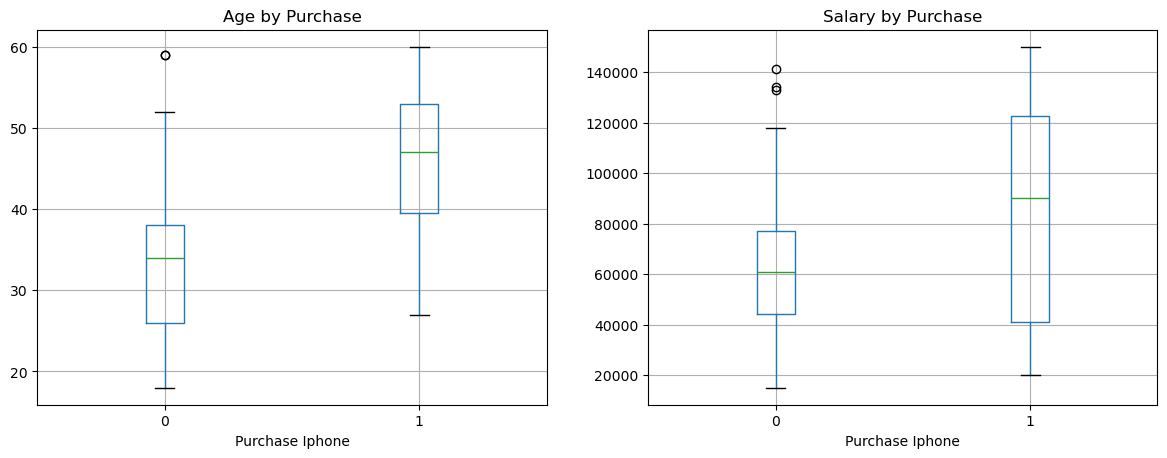

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Age', by='Purchase Iphone', ax=axes[0])
df.boxplot(column='Salary', by='Purchase Iphone', ax=axes[1])

axes[0].set_title('Age by Purchase')
axes[1].set_title('Salary by Purchase')
plt.suptitle('')
plt.show()

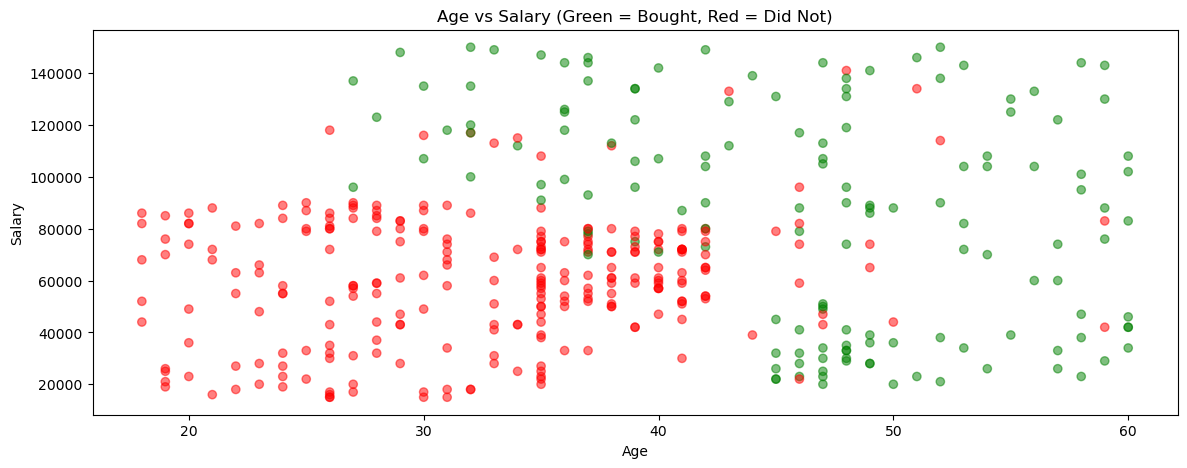

In [5]:
colors = df['Purchase Iphone'].map({0: 'red', 1: 'green'})
plt.figure(figsize=(14, 5))
plt.scatter(df['Age'], df['Salary'], c=colors, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary (Green = Bought, Red = Did Not)')
plt.show()

In [6]:
df['Gender'] = df['Gender'].astype(str).str.strip().str.capitalize()
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df.head()

,Gender,Age,Salary,Purchase Iphone
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


In [7]:
X =df[['Gender','Age','Salary']]
y = df['Purchase Iphone']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.20, random_state = 42)

In [13]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred = model.predict(X_test)
print("Decision Tree Accuracy :", accuracy_score(y_test,y_pred))
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))

Decision Tree Accuracy : 0.9125
Confusion Matrix: [[48  4]
 [ 3 25]]


In [16]:
def iphone_purchase_prediction(gender,age,salary):
    g_num = 1 if str(gender).lower() == "Male" else 0
    input_data = [[g_num,age,salary]]
    prob = model.predict_proba(input_data)[0][1]
    result = 'Yes' if prob >= 0.50 else 'No'
    print(f' \n input: {gender},Age = {age},Salary = {salary:,}')
    print(f'Result:{result}, Probability of buying iphone ={prob*100.:}%')

In [17]:
iphone_purchase_prediction('Male',40,85000)
iphone_purchase_prediction('Female',40,55000)

 
 input: Male,Age = 40,Salary = 85,000
Result:Yes, Probability of buying iphone =100.0%
 
 input: Female,Age = 40,Salary = 55,000
Result:No, Probability of buying iphone =9.090909090909092%
